# Geração de Conteúdo de Marketing com GANs (Redes Adversárias Generativas)

**1. Contexto de negócio**

Times de marketing frequentemente precisam de **variações visuais** de um mesmo
elemento gráfico — por exemplo, um selo promocional, um ícone de campanha ou um
"badge" de desconto — para testar em diferentes banners, redes sociais e
e-mails. Contratar um designer para desenhar manualmente dezenas de variações de
posição, tamanho e leve rotação de um mesmo ícone é lento e caro, especialmente
em fases de teste A/B em que o time quer experimentar rapidamente muitas opções
antes de decidir qual arte usar em escala.

Uma alternativa é treinar um modelo generativo que **aprenda o "estilo visual da
marca"** a partir de exemplos existentes e depois **gere novas variações
sozinho**, em segundos, sem intervenção humana a cada peça. Neste notebook vamos
construir, em miniatura, uma **GAN (Generative Adversarial Network)** — a mesma
classe de modelo por trás de ferramentas comerciais de geração de imagens — para
aprender a gerar variações de um ícone geométrico simples (um "selo" circular).

**2. Por que uma rede neural generativa ajuda aqui**

Uma GAN é composta por duas redes neurais que competem entre si:

- O **Gerador**: parte de um vetor de ruído aleatório (números sem significado
  algum) e tenta transformá-lo em uma imagem que pareça pertencer ao conjunto de
  imagens reais.
- O **Discriminador**: recebe imagens (reais ou geradas) e tenta adivinhar se
  cada uma é real (veio do dataset de exemplos da marca) ou falsa (foi criada
  pelo gerador).

As duas redes treinam juntas, em uma disputa: o discriminador fica melhor em
detectar falsificações, o que **força o gerador a melhorar** para enganá-lo. Com
o tempo, o gerador aprende a produzir imagens que capturam o **padrão
estatístico geral** do estilo visual da marca (forma, intensidade, distribuição
de pixels), mesmo criando variações que nunca existiram exatamente daquela
forma no dataset original.

Isso é útil em marketing porque permite gerar, sob demanda, muitas variações
plausíveis de um elemento visual sem precisar desenhar cada uma manualmente —
uma versão em miniatura do que ferramentas comerciais de geração de imagem
fazem em escala muito maior.

**3. Geração do dataset "real" simulado**

Vamos simular 500 imagens pequenas (16x16 pixels, escala de cinza, valores entre
0 e 1) representando um "selo" promocional: um círculo preenchido, sempre
reconhecível como o mesmo elemento de marca, mas com variações aleatórias de:

- **posição** (deslocamento do centro);
- **tamanho** (raio do círculo);
- **ruído leve** (textura/imperfeições, simulando variações de renderização).

Esse conjunto representa o "estilo visual consistente da marca" que queremos
que o gerador aprenda a replicar e variar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 16
N_REAL = 500

def gerar_selo(img_size=IMG_SIZE, seed=None):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:img_size, 0:img_size]

    centro = img_size / 2
    cx = centro + rng.uniform(-2.0, 2.0)
    cy = centro + rng.uniform(-2.0, 2.0)
    raio = rng.uniform(4.5, 6.5)

    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    # borda suave (anti-aliasing simples) em vez de circulo binario
    img = np.clip(raio - dist, -1.5, 1.5)
    img = (img + 1.5) / 3.0  # normaliza para ~[0,1]
    img = np.clip(img, 0.0, 1.0)

    ruido = rng.normal(0, 0.05, size=(img_size, img_size))
    img = np.clip(img + ruido, 0.0, 1.0)
    return img.astype("float32")

dataset_real = np.stack([gerar_selo(seed=i) for i in range(N_REAL)])
print(f"Dataset real simulado: {dataset_real.shape} imagens de {IMG_SIZE}x{IMG_SIZE}")
print(f"Intensidade media dos pixels: {dataset_real.mean():.4f} | desvio-padrao: {dataset_real.std():.4f}")

Dataset real simulado: (500, 16, 16) imagens de 16x16
Intensidade media dos pixels: 0.3879 | desvio-padrao: 0.4011


**4. Visualização de exemplos do dataset real**

Antes de treinar qualquer modelo, é sempre bom olhar para os dados. Abaixo, uma
amostra de 8 "selos" simulados — repare que todos são reconhecíveis como o
mesmo elemento de marca (um círculo preenchido central), mas com pequenas
variações de posição, tamanho e textura.

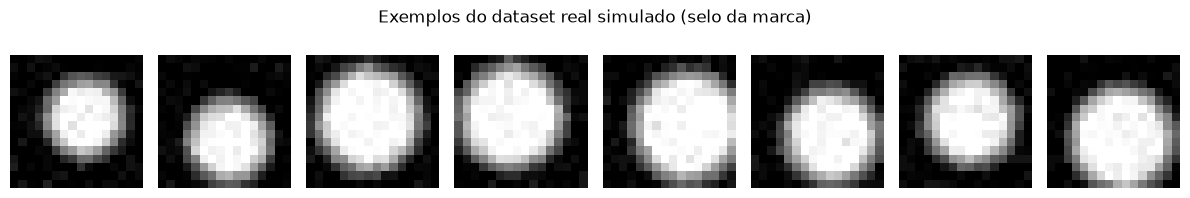

In [2]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(dataset_real[i], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Exemplos do dataset real simulado (selo da marca)")
plt.tight_layout()
plt.show()

**5. Definição do Gerador e do Discriminador**

- O **Gerador** recebe um vetor de ruído aleatório de dimensão 16 (o "espaço
  latente") e, por meio de camadas `Dense`, o transforma progressivamente até
  virar uma imagem 16x16 com ativação `sigmoid` (valores entre 0 e 1, como
  nossos pixels).
- O **Discriminador** faz o caminho inverso: recebe uma imagem 16x16
  (`Flatten`), passa por camadas `Dense` e termina em um único neurônio com
  ativação `sigmoid` que estima a probabilidade de a imagem ser real.

Ambos são propositalmente pequenos e rasos — o suficiente para o propósito
didático deste notebook, sem exigir muito tempo de treino.

In [3]:
LATENT_DIM = 16

def construir_gerador():
    modelo = keras.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(IMG_SIZE * IMG_SIZE, activation="sigmoid"),
        layers.Reshape((IMG_SIZE, IMG_SIZE)),
    ], name="gerador")
    return modelo

def construir_discriminador():
    modelo = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminador")
    return modelo

gerador = construir_gerador()
discriminador = construir_discriminador()

discriminador.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
discriminador.trainable = False

entrada_ruido = keras.Input(shape=(LATENT_DIM,))
imagem_gerada = gerador(entrada_ruido)
validade = discriminador(imagem_gerada)
gan = keras.Model(entrada_ruido, validade, name="gan")
gan.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy")

gerador.summary()
discriminador.summary()

Model: "gerador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,296 (75.38 KB)

 Trainable params: 19,296 (75.38 KB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,561 (72.50 KB)

**6. Loop de treino manual (Discriminador e Gerador alternados)**

O treino de uma GAN alterna dois passos a cada iteração:

1. **Treinar o Discriminador**: mostrar a ele um lote de imagens reais
   (rótulo 1) e um lote de imagens geradas pelo gerador atual (rótulo 0), e
   ajustar seus pesos para acertar essa distinção.
2. **Treinar o Gerador**: gerar um novo lote de imagens e ajustar os pesos do
   gerador (com o discriminador "congelado") para que o discriminador seja
   enganado e classifique essas imagens falsas como reais (rótulo 1).

Vamos treinar por poucas épocas — o suficiente para o gerador aprender a forma
e a textura geral do "selo", sem a pretensão de gerar imagens perfeitas.

In [4]:
BATCH_SIZE = 32
EPOCHS = 60

historico_d_loss = []
historico_g_loss = []

for epoca in range(EPOCHS):
    # --- passo 1: treinar o discriminador ---
    idx_reais = np.random.randint(0, dataset_real.shape[0], BATCH_SIZE)
    lote_real = dataset_real[idx_reais]

    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    lote_falso = gerador.predict(ruido, verbose=0)

    discriminador.trainable = True
    d_loss_real = discriminador.train_on_batch(lote_real, np.ones((BATCH_SIZE, 1)))
    d_loss_falso = discriminador.train_on_batch(lote_falso, np.zeros((BATCH_SIZE, 1)))
    d_loss = 0.5 * (np.add(d_loss_real, d_loss_falso))

    # --- passo 2: treinar o gerador (via modelo combinado, discriminador congelado) ---
    discriminador.trainable = False
    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    rotulos_enganar = np.ones((BATCH_SIZE, 1))
    g_loss = gan.train_on_batch(ruido, rotulos_enganar)

    historico_d_loss.append(d_loss[0])
    historico_g_loss.append(g_loss)

    if (epoca + 1) % 10 == 0:
        print(f"Epoca {epoca+1:3d}/{EPOCHS} | loss discriminador: {d_loss[0]:.4f} "
              f"(acc: {d_loss[1]:.2%}) | loss gerador: {g_loss:.4f}")

Epoca  10/60 | loss discriminador: 0.2474 (acc: 100.00%) | loss gerador: 1.9179
Epoca  20/60 | loss discriminador: 0.0902 (acc: 100.00%) | loss gerador: 2.7412


Epoca  30/60 | loss discriminador: 0.0856 (acc: 100.00%) | loss gerador: 2.8234
Epoca  40/60 | loss discriminador: 0.1245 (acc: 98.44%) | loss gerador: 3.0316


Epoca  50/60 | loss discriminador: 0.0615 (acc: 98.44%) | loss gerador: 3.6477
Epoca  60/60 | loss discriminador: 0.0285 (acc: 100.00%) | loss gerador: 3.5141


**7. Evolução das perdas durante o treino**

O gráfico abaixo mostra a "disputa" entre as duas redes. Não esperamos
convergência perfeita — GANs são notoriamente instáveis de treinar — mas
queremos ver as duas curvas se movimentando (nenhuma delas "vencendo" de forma
esmagadora e constante), o que indica que ambas as redes seguiram aprendendo.

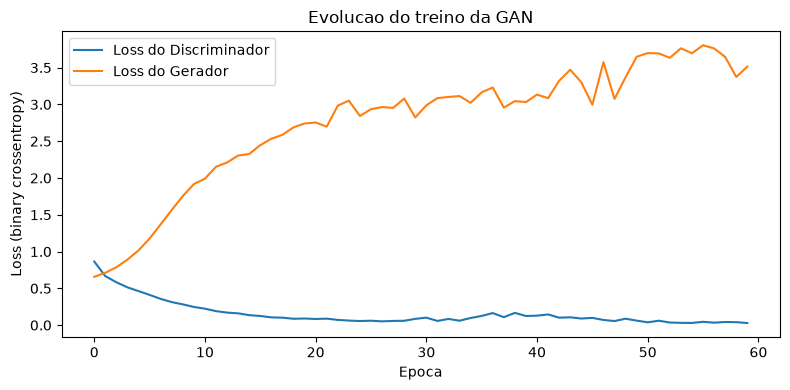

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(historico_d_loss, label="Loss do Discriminador")
plt.plot(historico_g_loss, label="Loss do Gerador")
plt.xlabel("Epoca")
plt.ylabel("Loss (binary crossentropy)")
plt.title("Evolucao do treino da GAN")
plt.legend()
plt.tight_layout()
plt.show()

**8. Geração de novas variações do "selo" após o treino**

Agora usamos apenas o gerador (já treinado) para criar novas imagens a partir
de vetores de ruído aleatório inéditos. Cada vetor de ruído diferente produz
uma variação diferente do selo — é assim que, na prática, o time de marketing
poderia gerar dezenas de variações em segundos.

In [6]:
N_GERAR = 8
ruido_novo = np.random.normal(0, 1, size=(N_GERAR, LATENT_DIM))
imagens_geradas = gerador.predict(ruido_novo, verbose=0)

print(f"Imagens geradas: {imagens_geradas.shape}")

Imagens geradas: (8, 16, 16)


**9. Comparação visual: imagens reais vs. imagens geradas**

Vamos colocar lado a lado uma amostra de imagens reais (linha de cima) e as
imagens geradas pelo modelo (linha de baixo). O objetivo não é que fiquem
idênticas pixel a pixel, mas que a **forma geral** (um círculo preenchido
central) e a **textura** sejam reconhecíveis como pertencentes ao mesmo estilo
visual.

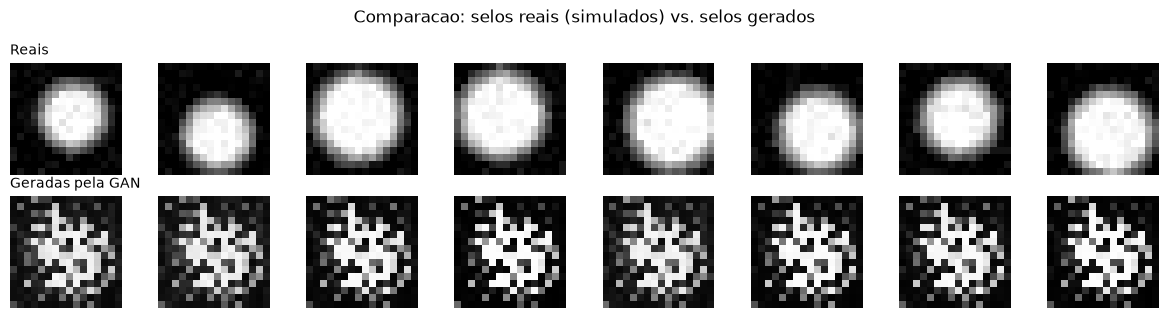

In [7]:
fig, axes = plt.subplots(2, N_GERAR, figsize=(12, 3.2))

for i in range(N_GERAR):
    axes[0, i].imshow(dataset_real[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")

for i in range(N_GERAR):
    axes[1, i].imshow(imagens_geradas[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_title("Reais", loc="left", fontsize=10)
axes[1, 0].set_title("Geradas pela GAN", loc="left", fontsize=10)
fig.suptitle("Comparacao: selos reais (simulados) vs. selos gerados")
plt.tight_layout()
plt.show()

**10. Comparação estatística entre imagens reais e geradas**

Além da inspeção visual, podemos comparar estatísticas simples de intensidade
de pixel entre os dois conjuntos: se o gerador aprendeu bem o padrão geral, a
média e o desvio-padrão de intensidade das imagens geradas devem ficar
**próximos** dos valores observados no dataset real, mesmo que as imagens
individuais não sejam idênticas.

In [8]:
media_real = dataset_real.mean()
std_real = dataset_real.std()
media_gerada = imagens_geradas.mean()
std_gerada = imagens_geradas.std()

print("Estatisticas de intensidade de pixel (0=preto, 1=branco)")
print(f"  Reais   -> media: {media_real:.4f} | desvio-padrao: {std_real:.4f}")
print(f"  Geradas -> media: {media_gerada:.4f} | desvio-padrao: {std_gerada:.4f}")
print(f"  Diferenca absoluta de media: {abs(media_real - media_gerada):.4f}")

Estatisticas de intensidade de pixel (0=preto, 1=branco)
  Reais   -> media: 0.3879 | desvio-padrao: 0.4011
  Geradas -> media: 0.3156 | desvio-padrao: 0.3650
  Diferenca absoluta de media: 0.0723


**11. Conclusão**

Com uma GAN bastante pequena e poucas épocas de treino, o gerador foi capaz de
aprender a reproduzir o **padrão visual geral** do "selo" da marca — a forma
circular central e a faixa de intensidade de pixel esperada — a partir apenas
de exemplos e de um sinal de disputa contra o discriminador, sem que
nenhuma regra geométrica explícita ("desenhe um círculo") tivesse sido
programada diretamente no gerador.

As imagens geradas não são cópias perfeitas do dataset real nem
indistinguíveis a olho nu de um design profissional — isso é esperado dado o
tamanho minúsculo da rede e o treino curto usados aqui por razões didáticas.
Mesmo assim, o experimento ilustra o princípio central: o modelo aprendeu a
**distribuição estatística** das imagens reais e consegue gerar novas
variações plausíveis sob demanda.

Esse é exatamente o mesmo princípio (gerador vs. discriminador competindo,
espaço latente de ruído transformado em conteúdo) usado por ferramentas
comerciais de geração de imagem e conteúdo de marketing — a diferença está na
escala: redes muito maiores, treinadas com milhões de imagens de alta
resolução por dias ou semanas em clusters de GPUs, em vez das 500 imagens de
16x16 pixels e 60 épocas usadas neste notebook. O valor de negócio, porém, é
o mesmo: reduzir o tempo e o custo de produzir variações visuais para testes
de campanha, liberando o time de design para decisões mais estratégicas em vez
de trabalho repetitivo de variação manual.